## EDA on the raw proteomics data from the SWISS100 cohort
- check age distribution across data
- check PCA to confirm Zurich samples as outliers 
- PCA by age 

In [6]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
PROJECT_ROOT = Path("/Users/achechenina/projects/centenerians")
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


In [7]:
swiss100_raw_npx = pd.read_csv(Path(PROJECT_ROOT) / "data/SWISS100/Univ_of_Geneve_Dept_of_Pathology_and_Immunology_NPX_2024-01-24.csv")
swiss100_raw_npx.head(3)

,SampleID,Group,1. Subject sex,1. Subject age,1.Ethnicity origin,Collection-Processing site,Delta storage (H:M:S),Delta storage (H:M:S)_Hour,Fasted,Delta breakfast (H:M:S),...,MissingFreq,Panel,Panel_Lot_Nr,PlateID,QC_Warning,LOD,NPX,Normalization,Assay_Warning,ExploreVersion
0,F2313457,Centenarian,Female,104.75,4. European Caucasian,Geneva,01:40:00,1.666667,No,02:00:00,...,0.5114,Inflammation,E50007,Sample_manifest_UniversitÃ© de GenÃ¨ve_plate_1,PASS,0.5195,-1.6271,Intensity,PASS,3.6.1
1,F2313490,Healthy,Female,32.00,4. European Caucasian,Ticino,06:30:00,6.500000,No,02:30:00,...,0.5114,Inflammation,E50007,Sample_manifest_UniversitÃ© de GenÃ¨ve_plate_1,PASS,0.5195,-1.4507,Intensity,PASS,3.6.1
2,F2313403,Healthy,Female,31.00,4. European Caucasian,Geneva,02:25:00,2.416667,No,01:50:00,...,0.5114,Inflammation,E50007,Sample_manifest_UniversitÃ© de GenÃ¨ve_plate_1,PASS,0.5195,0.1064,Intensity,PASS,3.6.1


In [8]:
swiss100_raw_npx.columns


Index(['SampleID', 'Group', '1. Subject sex', '1. Subject age',
       '1.Ethnicity origin', 'Collection-Processing site',
       'Delta storage (H:M:S)', 'Delta storage (H:M:S)_Hour', 'Fasted',
       'Delta breakfast (H:M:S)', 'Delta Breakfast (H:M:S)_Hour',
       'Delta processing (H:M:S)', 'Delta processing (H:M:S)_Hour',
       'Sample_Type', 'Index', 'OlinkID', 'UniProt', 'Assay', 'MissingFreq',
       'Panel', 'Panel_Lot_Nr', 'PlateID', 'QC_Warning', 'LOD', 'NPX',
       'Normalization', 'Assay_Warning', 'ExploreVersion'],
      dtype='object')

Rows (sample × assay): 129712
Unique samples: 176
Unique assays: 734

Group counts (sample-level):
Group
Healthy        60
Centenarian    59
Geriatric      57
Name: count, dtype: int64

Collection-Processing site:
Collection-Processing site
Geneva    96
Ticino    40
Zurich    40
Name: count, dtype: int64

Sex:
1. Subject sex
Female    111
Male       65
Name: count, dtype: int64

NPX missing fraction: 0.017639077340569877

Olink panel (long-format rows):
Panel
Cardiometabolic    64944
Inflammation       64768
Name: count, dtype: int64


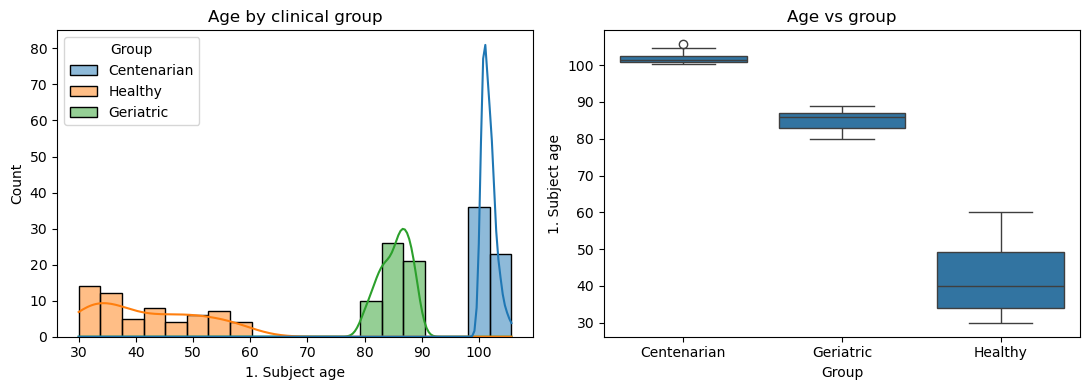

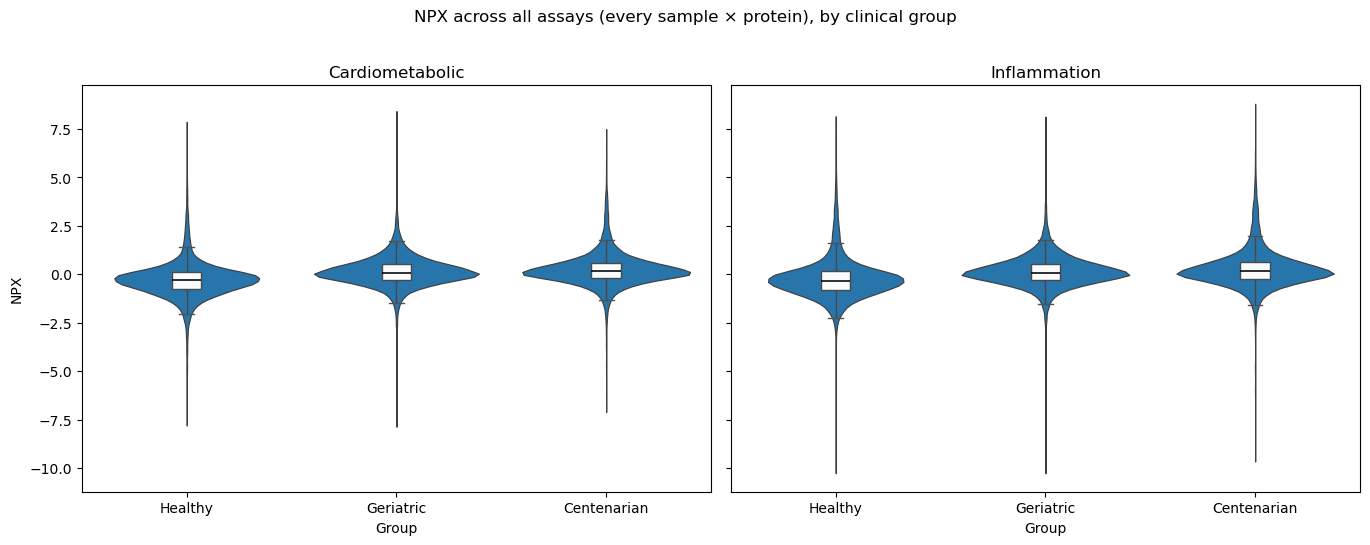

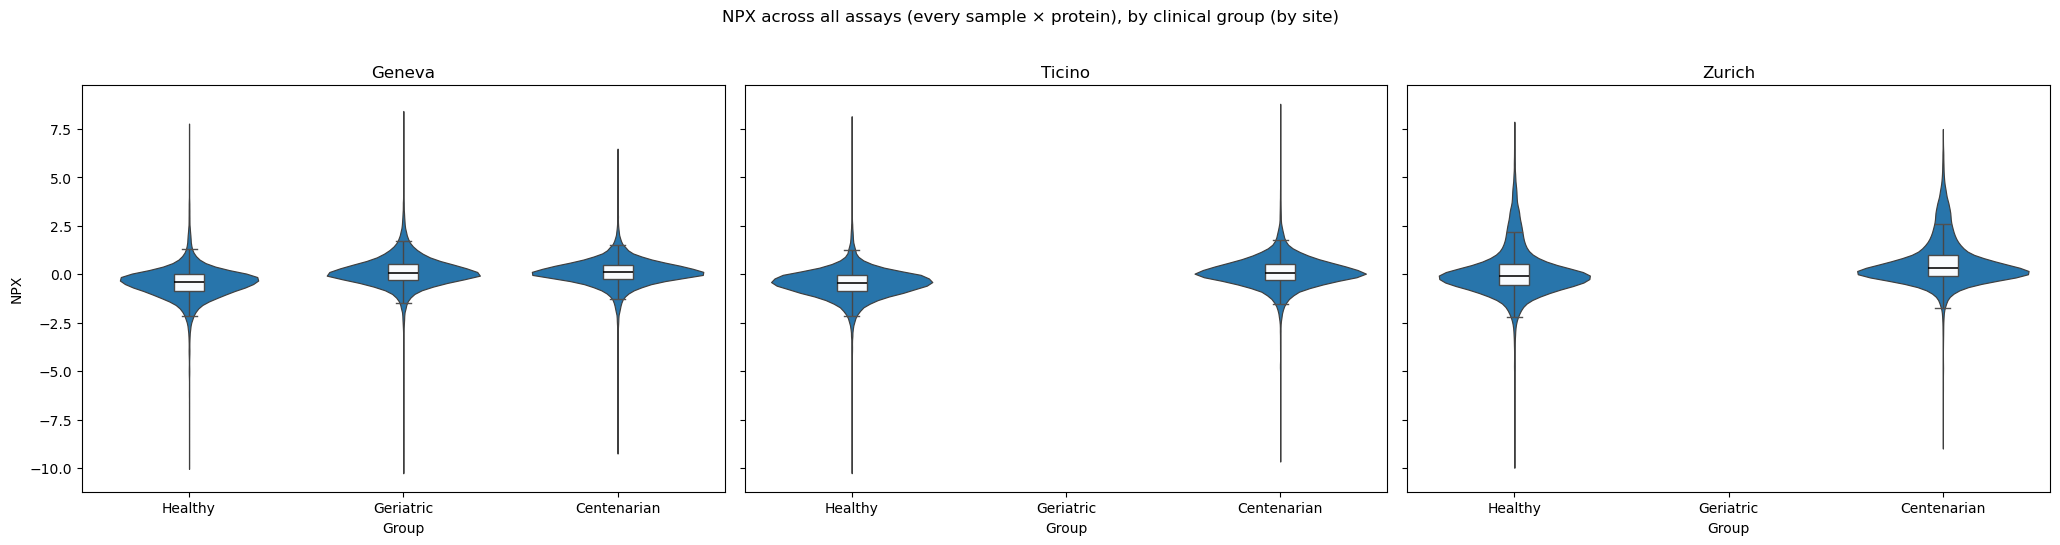

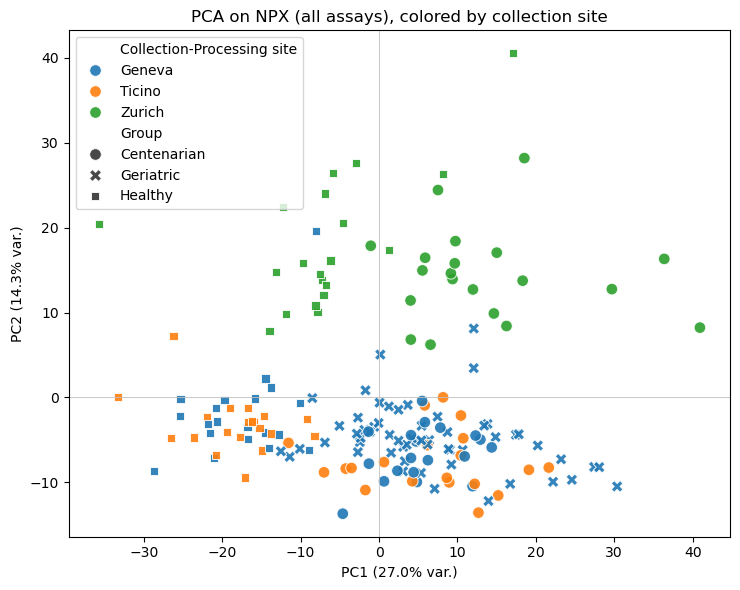

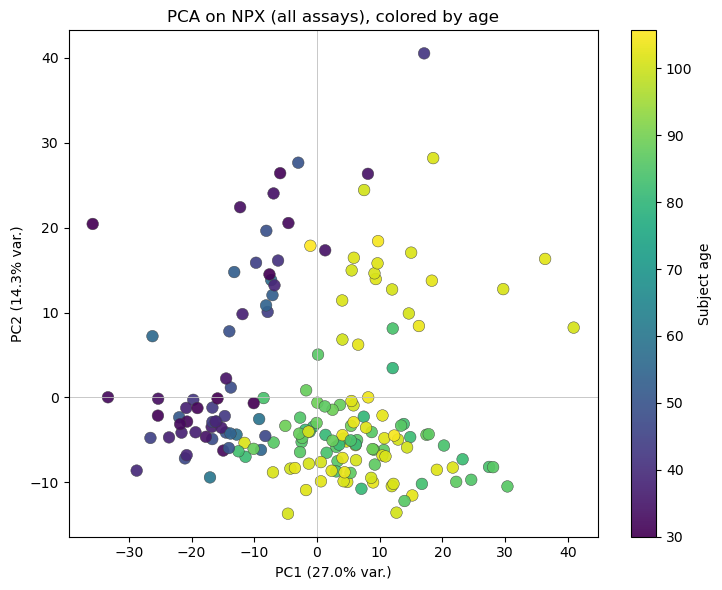

In [13]:
# EDA + PCA (long-format NPX → wide matrix per `SampleID`, assays as columns)

COL_GROUP = "Group"
COL_SITE = "Collection-Processing site"
COL_SEX = "1. Subject sex"
COL_AGE = "1. Subject age"
COL_ASSAY = "Assay"
COL_NPX = "NPX"
COL_PANEL = "Panel"
OUT_DIR = Path(PROJECT_ROOT) / "results" / "plots" / "EDA_SWISS100_raw"
OUT_DIR.mkdir(parents=True, exist_ok=True)

bio = swiss100_raw_npx[swiss100_raw_npx["Sample_Type"] == "SAMPLE"].copy()
bio[COL_AGE] = pd.to_numeric(bio[COL_AGE], errors="coerce")
bio[COL_NPX] = pd.to_numeric(bio[COL_NPX], errors="coerce")

print("Rows (sample × assay):", len(bio))
print("Unique samples:", bio["SampleID"].nunique())
print("Unique assays:", bio[COL_ASSAY].nunique())
print("\nGroup counts (sample-level):")
print(bio.drop_duplicates("SampleID")[COL_GROUP].value_counts())
print("\nCollection-Processing site:")
print(bio.drop_duplicates("SampleID")[COL_SITE].value_counts())
print("\nSex:")
print(bio.drop_duplicates("SampleID")[COL_SEX].value_counts())
print("\nNPX missing fraction:", float(bio[COL_NPX].isna().mean()))
print("\nOlink panel (long-format rows):")
print(bio[COL_PANEL].value_counts())

# --- Age distribution ---
_age = bio.drop_duplicates("SampleID")[[COL_GROUP, COL_AGE]].dropna()
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(data=_age, x=COL_AGE, hue=COL_GROUP, kde=True, ax=axes[0], multiple="layer", bins=20)
axes[0].set_title("Age by clinical group")
sns.boxplot(data=_age, x=COL_GROUP, y=COL_AGE, ax=axes[1], order=sorted(_age[COL_GROUP].dropna().unique()))
axes[1].set_title("Age vs group")
plt.tight_layout()
plt.savefig(OUT_DIR / "age_distribution.png")
plt.show()

# --- NPX across all proteins (all sample × assay rows), by clinical group, split by Olink panel ---
_grp_order = [g for g in ["Healthy", "Geriatric", "Centenarian"] if g in set(bio[COL_GROUP].dropna())]
_grp_order += [g for g in sorted(bio[COL_GROUP].dropna().unique()) if g not in _grp_order]
_panels = sorted(bio[COL_PANEL].dropna().unique())
_n_p = len(_panels)
fig, axes = plt.subplots(1, _n_p, figsize=(6.9 * _n_p, 5.3), sharey=True, squeeze=False)
axes = np.atleast_1d(axes).ravel()
for ax, pan in zip(axes, _panels):
    sub = bio[bio[COL_PANEL] == pan]
    sns.violinplot(
        data=sub,
        x=COL_GROUP,
        y=COL_NPX,
        order=_grp_order,
        ax=ax,
        cut=0,
        inner=None,
        linewidth=0.85,
        saturation=0.88,
    )
    sns.boxplot(
        data=sub,
        x=COL_GROUP,
        y=COL_NPX,
        order=_grp_order,
        ax=ax,
        width=0.14,
        showcaps=True,
        showfliers=False,
        boxprops={"facecolor": "white", "edgecolor": "0.28", "alpha": 0.98},
        medianprops={"color": "black", "linewidth": 1.15},
        whiskerprops={"color": "0.28"},
        zorder=4,
    )
    ax.set_title(pan)
    ax.set_xlabel(COL_GROUP)
axes[0].set_ylabel("NPX")
for _ax in axes[1:]:
    _ax.set_ylabel("")
fig.suptitle("NPX across all assays (every sample × protein), by clinical group", y=1.02, fontsize=12)
plt.tight_layout()
plt.savefig(OUT_DIR / "npx_overview_by_panel.png", dpi=300, bbox_inches="tight")
plt.show()

_grp_order = [g for g in ["Healthy", "Geriatric", "Centenarian"] if g in set(bio[COL_GROUP].dropna())]
_grp_order += [g for g in sorted(bio[COL_GROUP].dropna().unique()) if g not in _grp_order]
_sites = sorted(bio[COL_SITE].dropna().unique())
_n_sites = len(_sites)
fig, axes = plt.subplots(1, _n_sites, figsize=(6.9 * _n_sites, 5.3), sharey=True, squeeze=False)
axes = np.atleast_1d(axes).ravel()
for ax, site in zip(axes, _sites):
    sub = bio[bio[COL_SITE] == site]
    sns.violinplot(
        data=sub,
        x=COL_GROUP,
        y=COL_NPX,
        order=_grp_order,
        ax=ax,
        cut=0,
        inner=None,
        linewidth=0.85,
        saturation=0.88,
    )
    sns.boxplot(
        data=sub,
        x=COL_GROUP,
        y=COL_NPX,
        order=_grp_order,
        ax=ax,
        width=0.14,
        showcaps=True,
        showfliers=False,
        boxprops={"facecolor": "white", "edgecolor": "0.28", "alpha": 0.98},
        medianprops={"color": "black", "linewidth": 1.15},
        whiskerprops={"color": "0.28"},
        zorder=4,
    )
    ax.set_title(site)
    ax.set_xlabel(COL_GROUP)
axes[0].set_ylabel("NPX")
for _ax in axes[1:]:
    _ax.set_ylabel("")
fig.suptitle("NPX across all assays (every sample × protein), by clinical group (by site)", y=1.02, fontsize=12)
plt.tight_layout()
plt.savefig(OUT_DIR / "npx_overview_by_site.png", dpi=300, bbox_inches="tight")
plt.show()

# --- Wide matrix + PCA ---
wide = bio.pivot_table(index="SampleID", columns=COL_ASSAY, values=COL_NPX, aggfunc="mean")
# drop assays that are all missing
wide = wide.dropna(axis=1, how="all")
wide_imp = wide.apply(lambda s: s.fillna(s.median()), axis=0)

meta = (
    bio.drop_duplicates("SampleID")
    .set_index("SampleID")[[COL_GROUP, COL_SITE, COL_SEX, COL_AGE]]
    .loc[wide_imp.index]
)

X = StandardScaler().fit_transform(wide_imp.values)
pca = PCA(n_components=2, random_state=0)
pcs = pca.fit_transform(X)
plot_df = meta.assign(PC1=pcs[:, 0], PC2=pcs[:, 1])
ve = pca.explained_variance_ratio_

fig, ax = plt.subplots(figsize=(7.5, 6))
sns.scatterplot(
    data=plot_df,
    x="PC1",
    y="PC2",
    hue=COL_SITE,
    style=COL_GROUP,
    s=70,
    ax=ax,
    alpha=0.9,
)
ax.set_title("PCA on NPX (all assays), colored by collection site")
ax.set_xlabel(f"PC1 ({ve[0]*100:.1f}% var.)")
ax.set_ylabel(f"PC2 ({ve[1]*100:.1f}% var.)")
ax.axhline(0, color="0.75", lw=0.6)
ax.axvline(0, color="0.75", lw=0.6)
plt.tight_layout()
plt.savefig(OUT_DIR / "pca_all_assays.png")
plt.show()

fig, ax = plt.subplots(figsize=(7.5, 6))
sc = ax.scatter(
    plot_df["PC1"],
    plot_df["PC2"],
    c=plot_df[COL_AGE],
    cmap="viridis",
    s=70,
    edgecolor="0.25",
    linewidth=0.35,
    alpha=0.92,
)
cb = plt.colorbar(sc, ax=ax, label="Subject age")
ax.set_title("PCA on NPX (all assays), colored by age")
ax.set_xlabel(f"PC1 ({ve[0]*100:.1f}% var.)")
ax.set_ylabel(f"PC2 ({ve[1]*100:.1f}% var.)")
ax.axhline(0, color="0.75", lw=0.6)
ax.axvline(0, color="0.75", lw=0.6)
plt.tight_layout()
plt.savefig(OUT_DIR / "pca_all_assays_by_age.png")
plt.show()


Zurich is indeed very out, although within this group it seems like centenarians are similarly different from healthy to other cohorts.

In [15]:
swiss100_raw_npx[swiss100_raw_npx[COL_SITE] == "Zurich"].groupby(COL_GROUP)['SampleID'].nunique()

Group
Centenarian    20
Healthy        20
Name: SampleID, dtype: int64